In [12]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import dabest
import osar

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
#warnings.simplefilter(action="default", category=RuntimeWarning)

In [2]:
print(osar.__version__)

0.23.7


In [13]:
basegenotype = "SS75200"
responder = "ACR"
addNotes = basegenotype + " x " + responder

officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp

filedirectory = specifiedpath + "\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\"

baseDirectory = filedirectory + addNotes

if len(addNotes) > 0:
    addNotes = "_" + addNotes   
filename = baseDirectory + "\\" + basegenotype
filename_AppendDT = "_gen " + dt.datetime.today().strftime('%Y-%m-%d')

##### use this if you need to set filename manually
#filename = baseDirectory + "/" + "201230 R58E02-LexA;VT999036-Gal4 x Dop2R-RNAi;LexAOP-Chrimson_Female"

filename = filename + addNotes + filename_AppendDT

filename

'D:\\\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\SS75200 x ACR\\SS75200_SS75200 x ACR_gen 2025-03-12'

In [16]:
#color palette organizing

if responder == "Chrimson2":
    sibling_pi_color = "#c29999"
    pi_colors = "#cf0c16"

    sibling_sr_color = "#a8806f"
    sr_color = "#e0581d"
    
    
if responder == "ACR":
    sibling_pi_color = "#87ab89"
    pi_colors = "#0da315"

    sibling_sr_color = "#759c8c"
    sr_color = "#0fab6d"

my_color_palette_pi = {"Eighth; Sibling" : sibling_pi_color,
                      "Eighth; Offspring"    : pi_colors,
                    "Quarter; Sibling" : sibling_pi_color,
                      "Quarter; Offspring"    : pi_colors, 
                     "Half; Sibling" : sibling_pi_color,
                      "Half; Offspring"    : pi_colors,
                     "Full; Sibling" : sibling_pi_color,
                      "Full; Offspring"    : pi_colors
                     }


my_color_palette_sr = {"Eighth; Sibling" : sibling_sr_color,
                      "Eighth; Offspring"    : sr_color,
                    "Quarter; Sibling" : sibling_sr_color,
                      "Quarter; Offspring"    : sr_color, 
                     "Half; Sibling" : sibling_sr_color,
                      "Half; Offspring"    : sr_color,
                     "Full; Sibling" : sibling_sr_color,
                      "Full; Offspring"    : sr_color
                     }


In [15]:
#check for border shift
osarAnalysis = osar.osar(baseDirectory,
                        border_shift_mm = 0,  
                        # countlog_folder = "countlog_Full Only",         
                        # countlog_folder = "countlog_Half and Full",
                         driver = basegenotype)

Creating borders for each fly...
Done.

Processing CSV 64 of 64
Summarising results for all flies...
All done.


c:\Users\user\anaconda3\envs\dabesttestingenviro\lib\site-packages\dabest\plot_tools.py:2778: UserWarning: 61.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\dabesttestingenviro\lib\site-packages\dabest\plot_tools.py:2778: UserWarning: 28.1% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\dabesttestingenviro\lib\site-packages\dabest\plot_tools.py:2778: UserWarning: 61.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\dabesttestingenviro\lib\site-packages\dabest\plot_tools.py:2778: UserWarning: 23.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\dabesttestingenviro\lib\site-packages\dabest\plot_tools.py:2778: UserWarning: 65.8% of the points c

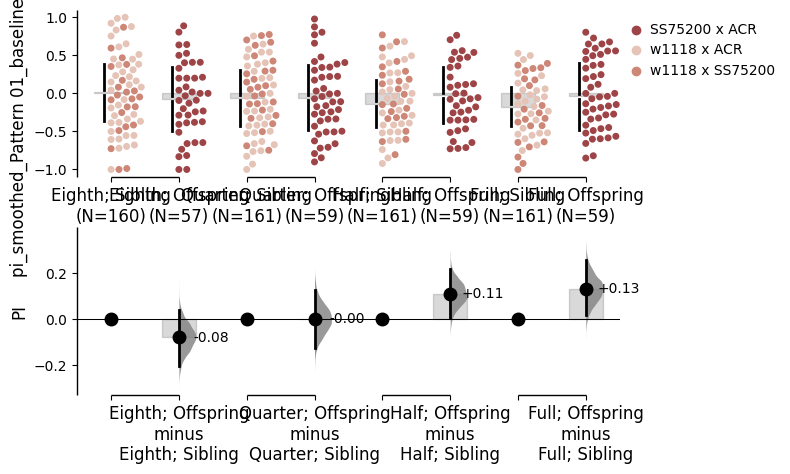

In [ ]:
#fulight = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"]
#newOA = singleplottingdabest(fulight, "SS75200", 'pi_smoothed_Pattern 01_baseline_corrected')

newOA = osarAnalysis.contrasts.pi.time_spent_in_light(epoch='first', baseline_corrected=True)
newOA.mean_diff.plot(contrast_ylim=(-2,2),                          
                               fig_size=(10,7), fontsize_rawylabel=12, fontsize_rawxlabel=8, 
                                fontsize_contrastxlabel=12, fontsize_contrastylabel=12, contrast_marker_size=6, 
                               #fig_size=(10,7), 
                               contrast_label="PI",
                               raw_marker_size= 1);



In [ ]:
osarFig_PI_Meandiff.savefig(filename + '.png', bbox_inches="tight", dpi=300)

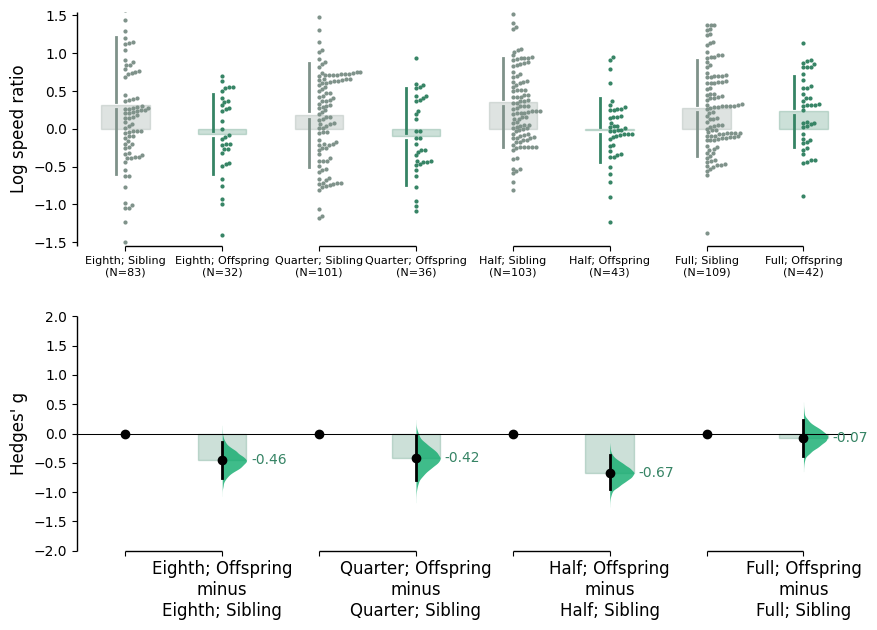

In [34]:
speedratio2 = osarAnalysis.contrasts.log2_speed_ratio.light_speed_against_dark_speed(epoch='first')

speedratio2.hedges_g.plot(custom_palette= my_color_palette_sr, fig_size=(10,7), fontsize_rawylabel=12, fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=12, fontsize_contrastylabel=12, es_marker_size=6,  swarm_ylim=(-1.55,1.55), 
                               contrast_ylim=(-2,2),
                               #fig_size=(10,7), 
                               swarm_label="Log speed ratio",
                               raw_marker_size= 1
                          );

#, swarm_ylim = (-20, 10), contrast_ylim = (-1, 1)

# sns.set(font_scale=0.7, style='ticks')
# speedratio2.mean_diff

In [57]:
osarFig_PI_Meandiff.savefig(filename + '.png', bbox_inches="tight", dpi=300)